## Convert VCF to PLINKconda

In [ ]:
!plink --vcf 'ALL.chr1.shapeit2_integrated_v1a.GRCh38.20181129.phased.vcf.gz' \
      --make-bed \
      --double-id \
      --vcf-half-call m \
      --set-missing-var-ids @:#:\$1:\$2 \
      --biallelic-only strict \
      --maf 0.05 \
      --geno 0.05 \
      --out chr1_raw

SyntaxError: invalid syntax (2839162195.py, line 1)

## LDA Pruning

In [6]:

!plink --bfile chr1_raw \
      --indep-pairwise 50 5 0.2 \
      --out chr1_pruned

PLINK v1.9.0-b.8 64-bit (22 Oct 2024)              cog-genomics.org/plink/1.9/
(C) 2005-2024 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to chr1_pruned.log.
Options in effect:
  --bfile chr1_raw
  --indep-pairwise 50 5 0.2
  --out chr1_pruned

32768 MB RAM detected; reserving 16384 MB for main workspace.
524865 variants loaded from .bim file.
2548 people (0 males, 0 females, 2548 ambiguous) loaded from .fam.
Ambiguous sex IDs written to chr1_pruned.nosex .
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 2548 founders and 0 nonfounders present.
Calculating allele frequencies... 10111213141516171819202122232425262728293031323334353637383940414243444546474849505152535455565758596061626364656667686970717273747576777879808182838485868788899091929394959697989 done.
Total genotyping rate is exactly 1.
524865 variants and 2548 people pass filters and QC.
Note: No phenotypes present.
Pruned 487277 variants from chromosome 1, leav

In [7]:
!plink --bfile chr1_raw \
      --extract chr1_pruned.prune.in \
      --make-bed \
      --out chr1_ldpruned

PLINK v1.9.0-b.8 64-bit (22 Oct 2024)              cog-genomics.org/plink/1.9/
(C) 2005-2024 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to chr1_ldpruned.log.
Options in effect:
  --bfile chr1_raw
  --extract chr1_pruned.prune.in
  --make-bed
  --out chr1_ldpruned

32768 MB RAM detected; reserving 16384 MB for main workspace.
524865 variants loaded from .bim file.
2548 people (0 males, 0 females, 2548 ambiguous) loaded from .fam.
Ambiguous sex IDs written to chr1_ldpruned.nosex .
--extract: 37588 variants remaining.
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 2548 founders and 0 nonfounders present.
Calculating allele frequencies... 10111213141516171819202122232425262728293031323334353637383940414243444546474849505152535455565758596061626364656667686970717273747576777879808182838485868788899091929394959697989 done.
Total genotyping rate is exactly 1.
37588 variants and 2548 people pass filters and QC.
Note: No phenot

## PCA

In [8]:
!plink --bfile chr1_ldpruned \
      --pca 10 \
      --out chr1_pca

PLINK v1.9.0-b.8 64-bit (22 Oct 2024)              cog-genomics.org/plink/1.9/
(C) 2005-2024 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to chr1_pca.log.
Options in effect:
  --bfile chr1_ldpruned
  --out chr1_pca
  --pca 10

32768 MB RAM detected; reserving 16384 MB for main workspace.
37588 variants loaded from .bim file.
2548 people (0 males, 0 females, 2548 ambiguous) loaded from .fam.
Ambiguous sex IDs written to chr1_pca.nosex .
Using up to 15 threads (change this with --threads).
Before main variant filters, 2548 founders and 0 nonfounders present.
Calculating allele frequencies... 10111213141516171819202122232425262728293031323334353637383940414243444546474849505152535455565758596061626364656667686970717273747576777879808182838485868788899091929394959697989 done.
Total genotyping rate is exactly 1.
37588 variants and 2548 people pass filters and QC.
Note: No phenotypes present.
Relationship matrix calculation complete.
--pca: Results saved to chr1_p

In [ ]:

!head chr1_pca.eigenvec
!wc -l chr1_pca.eigenvec

HG00096 HG00096 -0.0119138 0.0244254 0.0139386 0.0139167 -0.000501642 -0.00720385 -0.00982581 0.00257643 0.00229792 0.0049228
HG00097 HG00097 -0.0109402 0.0256483 0.0155579 0.01662 0.0013305 0.00170168 -0.0251798 -0.00622496 -0.000966517 -0.0511278
HG00099 HG00099 -0.011925 0.0268365 0.0177528 0.0139926 0.00185443 -0.00434208 -0.0202988 -0.0058052 0.00792129 0.00665396
HG00100 HG00100 -0.0114351 0.0262823 0.0155656 0.0115918 0.00473319 0.00430761 -0.00493831 0.00543444 -0.00547197 -0.028379
HG00101 HG00101 -0.0125192 0.0271903 0.0191683 0.0113888 0.00420949 0.0113135 -0.0309582 0.00337661 0.00277618 0.0128344
HG00102 HG00102 -0.0109365 0.0262518 0.0167496 0.0175881 0.00956982 -0.0056254 0.00377616 -0.00441056 0.000849631 0.0248837
HG00103 HG00103 -0.0117864 0.0263528 0.0155114 0.014123 0.0033996 -0.00572931 -0.0142963 0.00019232 0.00274458 0.0130462
HG00104 HG00104 -0.0125263 0.0278034 0.0156296 0.0123971 0.00304759 0.00778994 -0.00758033 -0.000679275 -1.53697e-05 -0.00685692
HG00105 H

## MERGE AND PLOT

Unmatched samples: 45


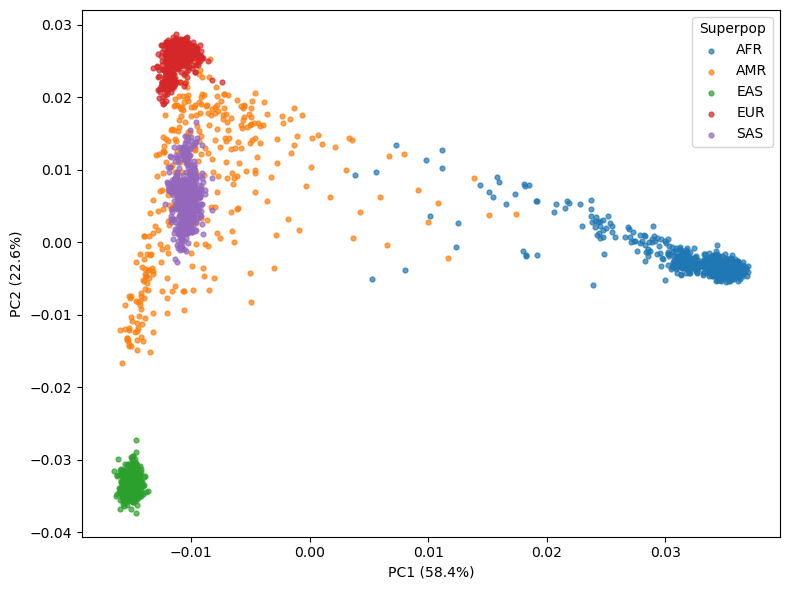

In [1]:
import pandas as pd
import matplotlib.pyplot as plt


pca = pd.read_csv('chr1_pca.eigenvec', sep=r'\s+', header=None,
                  names=['FID', 'IID'] + [f'PC{i}' for i in range(1, 11)])


eigenvals = pd.read_csv('chr1_pca.eigenval', header=None, names=['eigenvalue'])
pct_var = 100 * eigenvals['eigenvalue'] / eigenvals['eigenvalue'].sum()


pops = pd.read_csv('sample_type.csv')


df = pca.merge(pops, left_on='IID', right_on='sample', how='left')


print('Unmatched samples:', df['Superpopulation'].isna().sum())


fig, ax = plt.subplots(figsize=(8, 6))
for sp, sub in df.groupby('Superpopulation'):
    ax.scatter(sub['PC1'], sub['PC2'], label=sp, s=12, alpha=0.7)
ax.set_xlabel(f'PC1 ({pct_var[0]:.1f}%)')
ax.set_ylabel(f'PC2 ({pct_var[1]:.1f}%)')
ax.legend(title='Superpop')
plt.tight_layout()
plt.show()

## ADMIXTURE

In [2]:
!admixture --cv chr1_ldpruned.bed 2.5 -j4 | tee chr1_ldpruned.logK2.5.out

****                   ADMIXTURE Version 1.3.0                  ****
****                    Copyright 2008-2015                     ****
****           David Alexander, Suyash Shringarpure,            ****
****                John  Novembre, Ken Lange                   ****
****                                                            ****
****                 Please cite our paper!                     ****
****   Information at www.genetics.ucla.edu/software/admixture  ****

Cross-validation will be performed.  Folds=5.
Parallel execution requested.  Will use 4 threads.
Random seed: 43
Point estimation method: Block relaxation algorithm
Convergence acceleration algorithm: QuasiNewton, 3 secant conditions
Point estimation will terminate when objective function delta < 0.0001
Estimation of standard errors disabled; will compute point estimates only.
Size of G: 2548x37588
Performing five EM steps to prime main algorithm
1 (EM) 	Elapsed: 4.112	Loglikelihood: -9.07482e+07	(delta): 7.326

In [ ]:
!admixture chr1_ldpruned.bed 4 -j4 | tee chr1_ldpruned.logK4.out

****                   ADMIXTURE Version 1.3.0                  ****
****                    Copyright 2008-2015                     ****
****           David Alexander, Suyash Shringarpure,            ****
****                John  Novembre, Ken Lange                   ****
****                                                            ****
****                 Please cite our paper!                     ****
****   Information at www.genetics.ucla.edu/software/admixture  ****

Cross-validation will be performed.  Folds=5.
Parallel execution requested.  Will use 4 threads.
Random seed: 43
Point estimation method: Block relaxation algorithm
Convergence acceleration algorithm: QuasiNewton, 3 secant conditions
Point estimation will terminate when objective function delta < 0.0001
Estimation of standard errors disabled; will compute point estimates only.
Size of G: 2548x37588
Performing five EM steps to prime main algorithm
1 (EM) 	Elapsed: 7.352	Loglikelihood: -9.18942e+07	(delta): 5.703

In [4]:
!admixture chr1_ldpruned.bed 8 -j6 | tee chr1_ldpruned.logK8.out

****                   ADMIXTURE Version 1.3.0                  ****
****                    Copyright 2008-2015                     ****
****           David Alexander, Suyash Shringarpure,            ****
****                John  Novembre, Ken Lange                   ****
****                                                            ****
****                 Please cite our paper!                     ****
****   Information at www.genetics.ucla.edu/software/admixture  ****

Parallel execution requested.  Will use 6 threads.
Random seed: 43
Point estimation method: Block relaxation algorithm
Convergence acceleration algorithm: QuasiNewton, 3 secant conditions
Point estimation will terminate when objective function delta < 0.0001
Estimation of standard errors disabled; will compute point estimates only.
Size of G: 2548x37588
Performing five EM steps to prime main algorithm
1 (EM) 	Elapsed: 14.482	Loglikelihood: -9.15518e+07	(delta): 4.93573e+07
2 (EM) 	Elapsed: 14.839	Loglikelihood:

In [10]:

%%bash
for K in 4 5 6 7; do
    admixture chr1_ldpruned.bed $K -j6 | tee chr1_ldpruned.log${K}.out
done

****                   ADMIXTURE Version 1.3.0                  ****
****                    Copyright 2008-2015                     ****
****           David Alexander, Suyash Shringarpure,            ****
****                John  Novembre, Ken Lange                   ****
****                                                            ****
****                 Please cite our paper!                     ****
****   Information at www.genetics.ucla.edu/software/admixture  ****

Parallel execution requested.  Will use 6 threads.
Random seed: 43
Point estimation method: Block relaxation algorithm
Convergence acceleration algorithm: QuasiNewton, 3 secant conditions
Point estimation will terminate when objective function delta < 0.0001
Estimation of standard errors disabled; will compute point estimates only.
Size of G: 2548x37588
Performing five EM steps to prime main algorithm
1 (EM) 	Elapsed: 7.552	Loglikelihood: -9.18942e+07	(delta): 5.7032e+07
2 (EM) 	Elapsed: 7.469	Loglikelihood: -8

### Visualization with PONG

In [11]:
import csv


sample_to_pop = {}
with open('sample_type.csv') as f:
    reader = csv.DictReader(f)   # delimiter='\t' if TSV
    for row in reader:
        sample_to_pop[row['sample']] = row['Population']


with open('chr1_ldpruned.fam') as f, open('chr1_ldpruned.ind2pop', 'w') as out:
    for line in f:
        iid = line.split()[1]
        pop = sample_to_pop.get(iid, 'Unknown')
        out.write(pop + '\n')


import collections
with open('chr1_ldpruned.ind2pop') as f:
    counts = collections.Counter(line.strip() for line in f)
print(counts)
print('Total:', sum(counts.values()), '(should be 2548)')

Counter({'GWD': 113, 'IBS': 107, 'YRI': 107, 'TSI': 107, 'CHS': 105, 'PUR': 104, 'JPT': 104, 'CHB': 103, 'GIH': 103, 'STU': 102, 'ITU': 102, 'FIN': 99, 'KHV': 99, 'ESN': 99, 'CEU': 99, 'LWK': 99, 'PJL': 96, 'ACB': 96, 'CLM': 94, 'CDX': 93, 'GBR': 91, 'BEB': 86, 'PEL': 85, 'MSL': 85, 'MXL': 64, 'ASW': 61, 'Unknown': 45})
Total: 2548 (should be 2548)


In [13]:
%%bash
prefix=chr1_ldpruned
> ${prefix}.Qfilemap
for K in 4 5 6 7 8; do
    printf "Run${K}\t${K}\t${prefix}.${K}.Q\n" >> ${prefix}.Qfilemap
done
cat ${prefix}.Qfilemap

Run4	4	chr1_ldpruned.4.Q
Run5	5	chr1_ldpruned.5.Q
Run6	6	chr1_ldpruned.6.Q
Run7	7	chr1_ldpruned.7.Q
Run8	8	chr1_ldpruned.8.Q


In [14]:
!pong -m chr1_ldpruned.Qfilemap -i chr1_ldpruned.ind2pop


-------------------------------------------------------------------
                            p o n g
      by A. Behr, K. Liu, T. Devlin, G. Liu-Fang, and S. Ramachandran
                       Version 1.5 (2021)
-------------------------------------------------------------------
-------------------------------------------------------------------

Parsing input and generating cluster network graph
Matching clusters within each K and finding representative runs
For K=4, there is 1 mode across 1 run.
For K=5, there is 1 mode across 1 run.
For K=6, there is 1 mode across 1 run.
For K=7, there is 1 mode across 1 run.
For K=8, there is 1 mode across 1 run.
Matching clusters across K
Finding best alignment for all runs within and across K
match time: 0.46s
align time: 0.01s
total time: 0.56s
-----------------------------------------------------------
pong server is now running locally & listening on port 4000
Open your web browser and navigate to http://localhost:4000 to see the visualiz


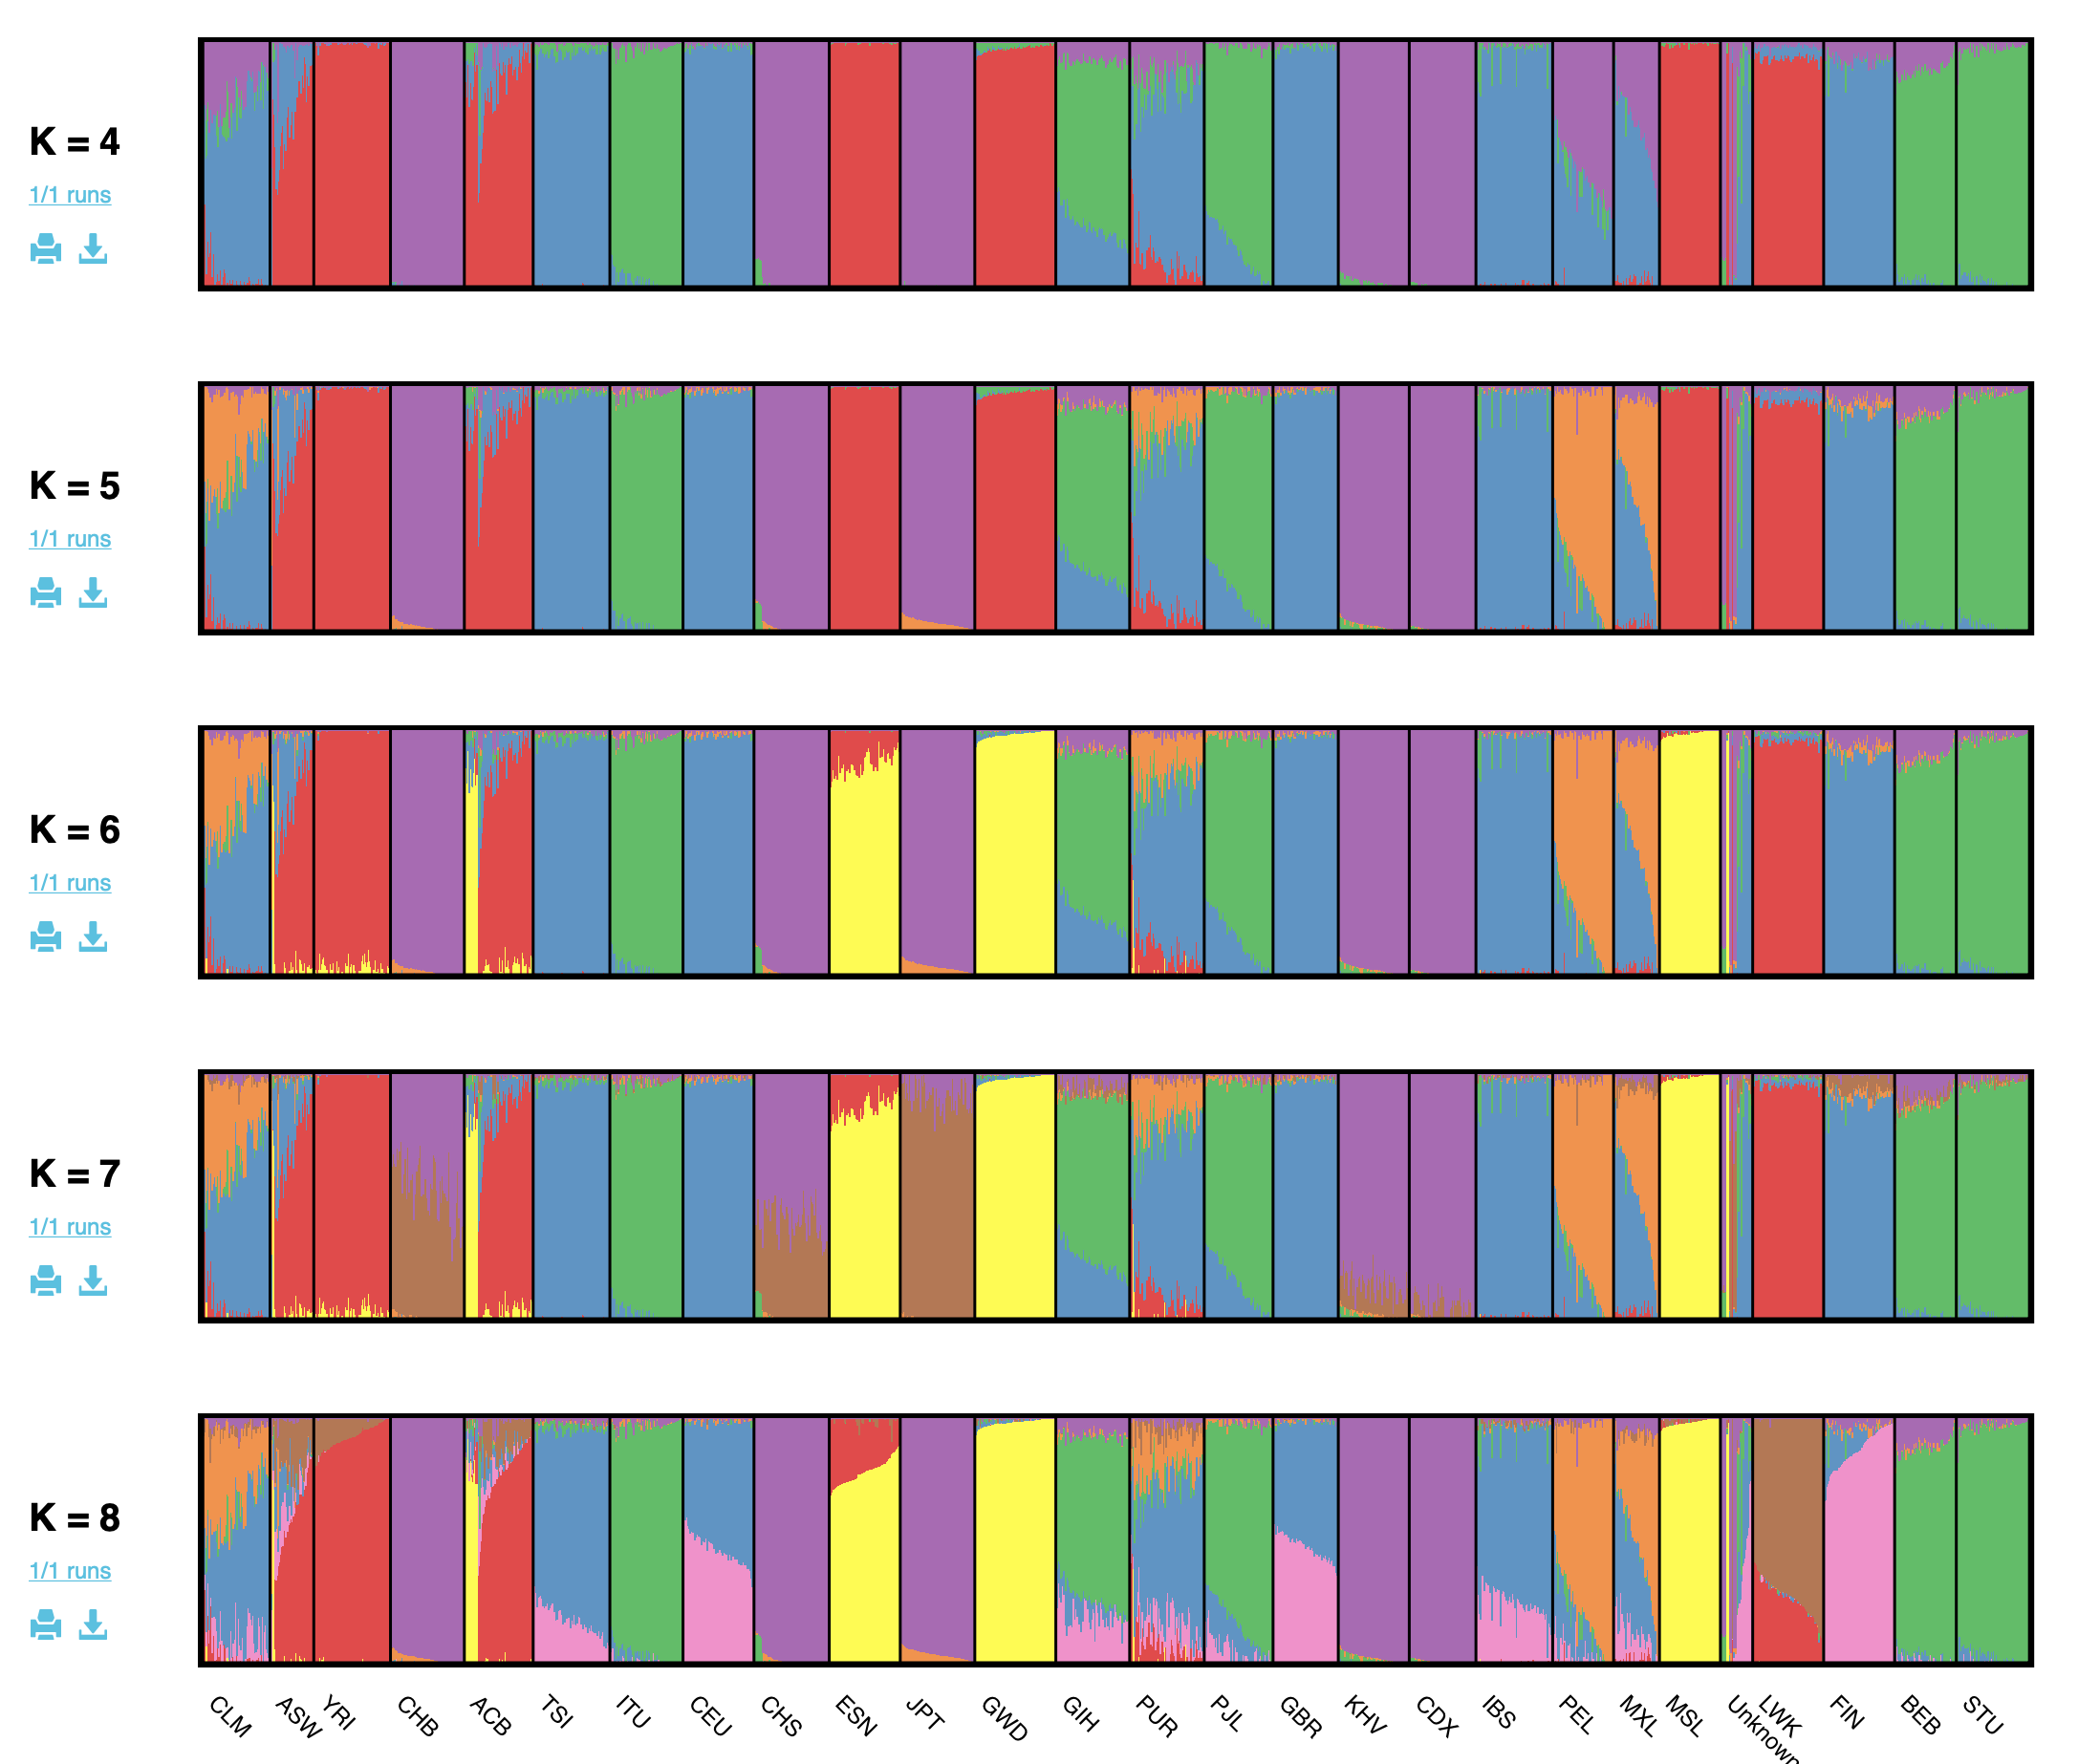







## With super population:

In [ ]:
import csv


sample_to_superpop = {}
with open('sample_type.csv') as f:
    reader = csv.DictReader(f)
    for row in reader:
        sample_to_superpop[row['sample']] = row['Superpopulation']


with open('chr1_ldpruned.fam') as f, open('chr1_ldpruned.ind2superpop', 'w') as out:
    for line in f:
        iid = line.split()[1]
        out.write(sample_to_superpop.get(iid, 'Unknown') + '\n')


import collections
with open('chr1_ldpruned.ind2superpop') as f:
    print(collections.Counter(line.strip() for line in f))



Counter({'AFR': 660, 'EAS': 504, 'EUR': 503, 'SAS': 489, 'AMR': 347, 'Unknown': 45})
 - python >= 3.7 (installed: v3.10),
 - numpy >= 1.18 (installed: 2.2.6),
 - munkres >= 1.1 (installed: 1.1.4),
 - networkx >= 2.4 (installed: 2.8.8),
 - tornado >= 6 (installed: 6.5.5).
We recommend upgrading these modules, otherwise you may
experience issues running pong.
Continue anyway? (y/n): ^C


In [30]:
!pong -m chr1_ldpruned.Qfilemap -i chr1_ldpruned.ind2superpop --port 4001

 - python >= 3.7 (installed: v3.10),
 - numpy >= 1.18 (installed: 2.2.6),
 - munkres >= 1.1 (installed: 1.1.4),
 - networkx >= 2.4 (installed: 2.8.8),
 - tornado >= 6 (installed: 6.5.5).
We recommend upgrading these modules, otherwise you may
experience issues running pong.
Continue anyway? (y/n): ^C



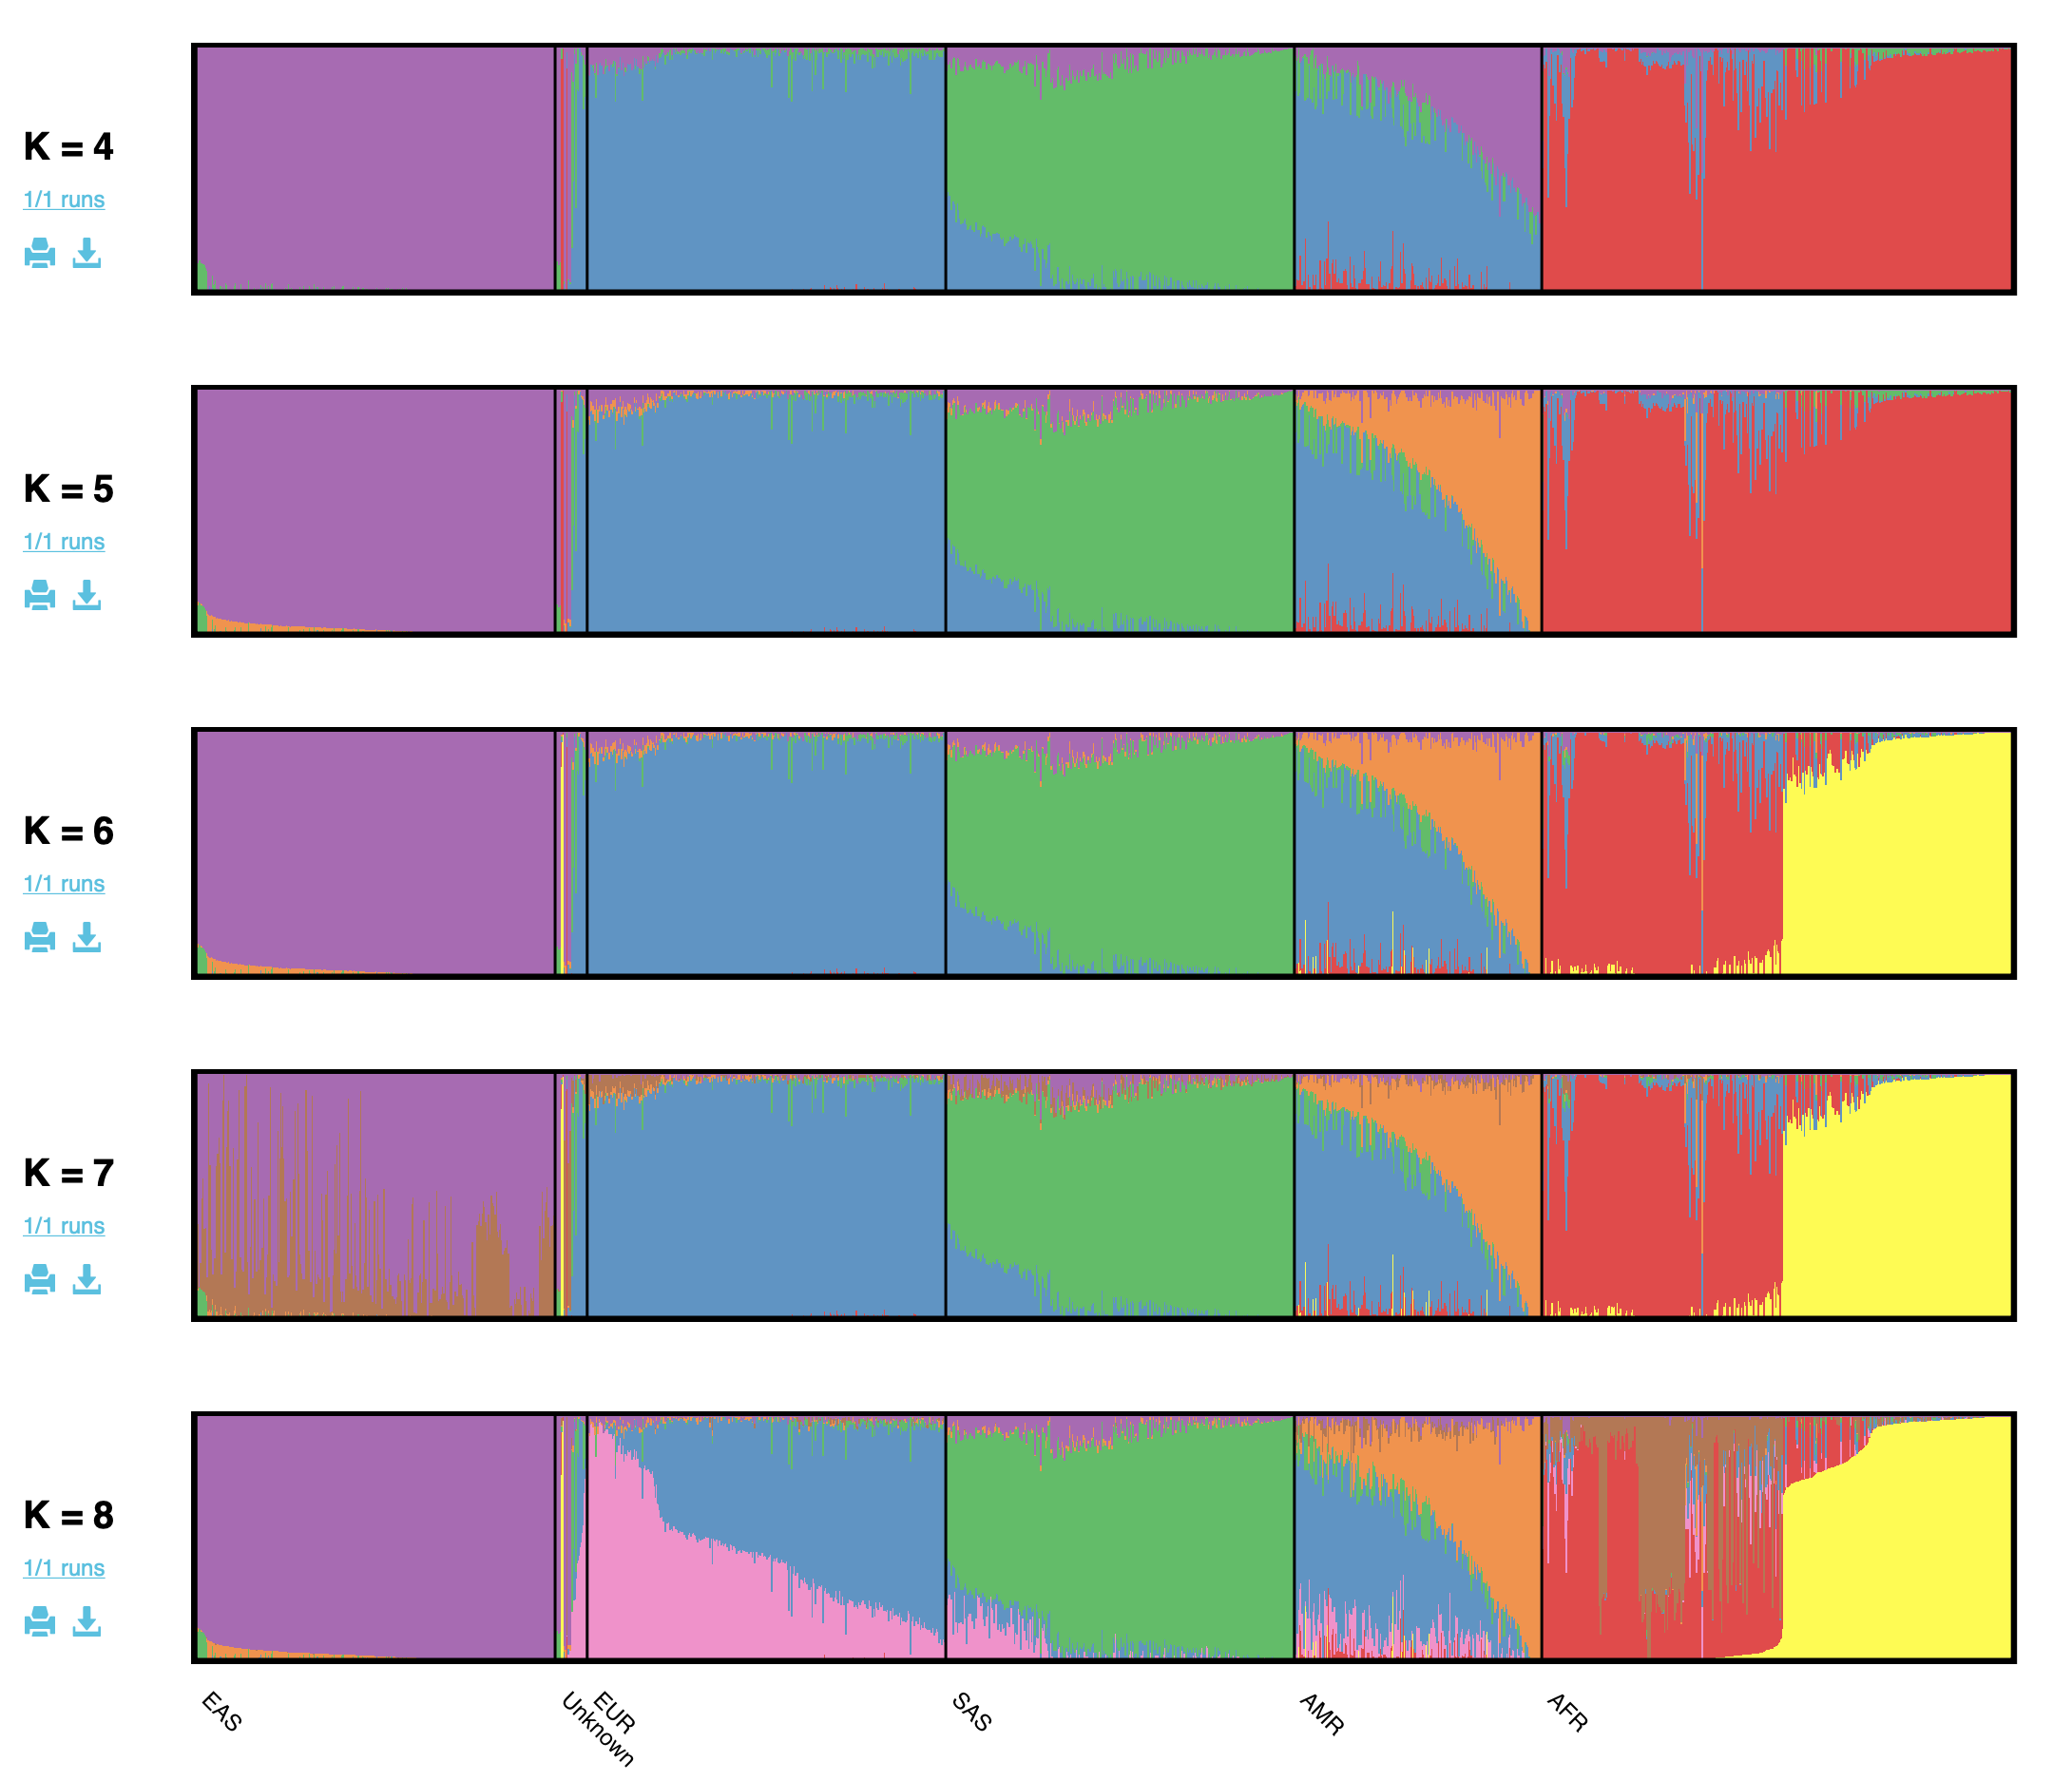



# Answer / Interpretation Exercise 1

- Red → African ancestry. Lights up the AFR column almost entirely.
- Blue → European ancestry. Dominates the EUR column.
- Purple → East Asian ancestry. Dominates the EAS column.
- Green → South Asian ancestry. Dominates the SAS column.
- Orange → Native American ancestry. Strong in part of the AMR column

**Steps:**

- **VCF → PLINK** conversion: Converted the 1000 Genomes chr1 biallelic SNV VCF (~6M variants, 2,548 samples) to PLINK binary format with MAF ≥ 5% and missingness ≤ 5% filters, retaining 524,865 SNPs.

- **LD pruning**: Used --indep-pairwise 50 5 0.2 to remove correlated SNPs, leaving 37,588 approximately independent markers suitable for PCA and ADMIXTURE assumptions.
PCA: Computed the top 10 principal components with PLINK's --pca, projecting samples into a low-dimensional ancestry space.

- **ADMIXTURE**: Ran the algorithm for K=4 through K=8 to estimate per-sample ancestry proportions across multiple cluster numbers, then visualized with pong using both population-level and super-population-level grouping.

**Interpretation**: PC1 vs PC2 cleanly separates the five continental super-populations (AFR, EUR, EAS, SAS, AMR), with AMR samples spreading along an admixture cline rather than forming a tight cluster. ADMIXTURE recovers the same five-component structure at K=5: African, European, East Asian, South Asian, and Native American ancestries. African, European, East Asian, and South Asian populations show near-homogeneous ancestry profiles, while admixed populations (ASW, ACB, MXL, CLM, PUR, PEL) show characteristic multi-component mixtures consistent with their documented colonial-era admixture history. Higher K values reveal sub-continental structure within Africa (K=6+) and Europe (K=7+).


# Exercise 2

In [ ]:
import pandas as pd

df = pd.read_csv('kg_matrix_chr1.csv')

print('Shape:', df.shape)
print('\nFirst 5 rows, first 8 columns:')
print(df.iloc[:5, :8])
print('\nColumn names (first 20):')
print(list(df.columns[:20]))
print('\nDtypes (first 10):')
print(df.dtypes.head(10))

Shape: (30635, 3203)

First 5 rows, first 8 columns:
   Unnamed: 0  NA19024  HG03117  NA19120  HG03492  NA19238  NA19148  HG01956
0           0     23.0     23.0     23.5     23.0     24.0     23.0     23.0
1           1     24.5     25.0     25.0     26.0     24.5     25.0     25.5
2           2     19.0     19.0     18.0     19.0     19.0     21.0     19.0
3           3     20.5     23.0     23.0     22.0     23.0     20.5     23.0
4           4     13.0     13.0     13.0     10.5     10.5     13.0     13.0

Column names (first 20):
['Unnamed: 0', 'NA19024', 'HG03117', 'NA19120', 'HG03492', 'NA19238', 'NA19148', 'HG01956', 'HG00284', 'NA19404', 'HG01530', 'NA19445', 'HG01978', 'HG01200', 'HG01126', 'NA20532', 'HG01086', 'NA18934', 'HG03595', 'HG02078']

Dtypes (first 10):
Unnamed: 0      int64
NA19024       float64
HG03117       float64
NA19120       float64
HG03492       float64
NA19238       float64
NA19148       float64
HG01956       float64
HG00284       float64
NA19404       flo

In [17]:
import pandas as pd
import numpy as np

df = pd.read_csv('kg_matrix_chr1.csv')


df = df.drop(columns=['Unnamed: 0'])

print('After dropping index column:')
print('  Loci × samples:', df.shape)

n_missing_per_locus = df.isna().sum(axis=1)
print(f'  Loci with any missing data: {(n_missing_per_locus > 0).sum()}')
print(f'  Loci with >5% missing:      {(n_missing_per_locus > 0.05 * df.shape[1]).sum()}')


locus_variance = df.var(axis=1)
print(f'  Loci with zero variance:    {(locus_variance == 0).sum()}')
print(f'  Loci with very low variance (<0.01): {(locus_variance < 0.01).sum()}')


n_alleles = df.nunique(axis=1)
print(f'  Median distinct alleles per locus: {n_alleles.median():.0f}')
print(f'  Loci with only 1 distinct value:   {(n_alleles == 1).sum()}')
print(f'  Loci with only 2 distinct values:  {(n_alleles == 2).sum()}')

After dropping index column:
  Loci × samples: (30635, 3202)
  Loci with any missing data: 10870
  Loci with >5% missing:      2156
  Loci with zero variance:    0
  Loci with very low variance (<0.01): 0
  Median distinct alleles per locus: 12
  Loci with only 1 distinct value:   0
  Loci with only 2 distinct values:  11


In [19]:
import pandas as pd
import numpy as np

df = pd.read_csv('kg_matrix_chr1.csv').drop(columns=['Unnamed: 0'])


n_samples = df.shape[1]
keep_loci = df.isna().sum(axis=1) <= 0.05 * n_samples
df = df.loc[keep_loci]
print(f'After missingness filter: {df.shape[0]} loci × {df.shape[1]} samples')


df = df.apply(lambda row: row.fillna(row.median()), axis=1)
print(f'Remaining NaNs: {df.isna().sum().sum()} (should be 0)')


X = df.T   # rows = samples, columns = loci
X.index.name = 'sample'
print(f'Matrix for PCA: {X.shape[0]} samples × {X.shape[1]} loci')

After missingness filter: 28479 loci × 3202 samples
Remaining NaNs: 0 (should be 0)
Matrix for PCA: 3202 samples × 28479 loci


In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA



scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


pca = PCA(n_components=10)
pcs = pca.fit_transform(X_scaled)


var_explained = 100 * pca.explained_variance_ratio_
print('Variance explained per PC (%):')
for i, v in enumerate(var_explained, 1):
    print(f'  PC{i}: {v:.2f}%')
print(f'  Total (PC1-10): {var_explained.sum():.2f}%')


pcs_df = pd.DataFrame(pcs, index=X.index,
                      columns=[f'PC{i}' for i in range(1, 11)])
pcs_df = pcs_df.reset_index()  # make 'sample' a regular column
print(pcs_df.head())

Variance explained per PC (%):
  PC1: 8.51%
  PC2: 3.15%
  PC3: 0.93%
  PC4: 0.73%
  PC5: 0.26%
  PC6: 0.19%
  PC7: 0.15%
  PC8: 0.15%
  PC9: 0.14%
  PC10: 0.14%
  Total (PC1-10): 14.36%
    sample        PC1        PC2        PC3       PC4        PC5        PC6  \
0  NA19024  79.999954  -3.314455  -0.200383  1.455431   6.337168  -9.593088   
1  HG03117  85.398650  -4.461893   0.056232  0.952641 -13.471653 -12.855080   
2  NA19120  84.662797  -8.285575   2.379744 -1.830102   6.851343 -19.058311   
3  HG03492 -26.352944  15.680904 -18.709424  8.897718   0.521760   0.961853   
4  NA19238  83.816360  -6.074424   2.309252  1.938464  -3.361025 -13.804111   

         PC7       PC8        PC9      PC10  
0 -15.914923 -1.419440   3.640890 -5.026302  
1   0.550934 -5.609554  -4.036375  2.106174  
2  -0.143698  4.248996   1.510221  8.374149  
3   6.122355  6.294617   2.714054 -1.516517  
4  -1.408244 -0.809842 -15.317043  2.492695  


Samples without population label: 0 / 3202


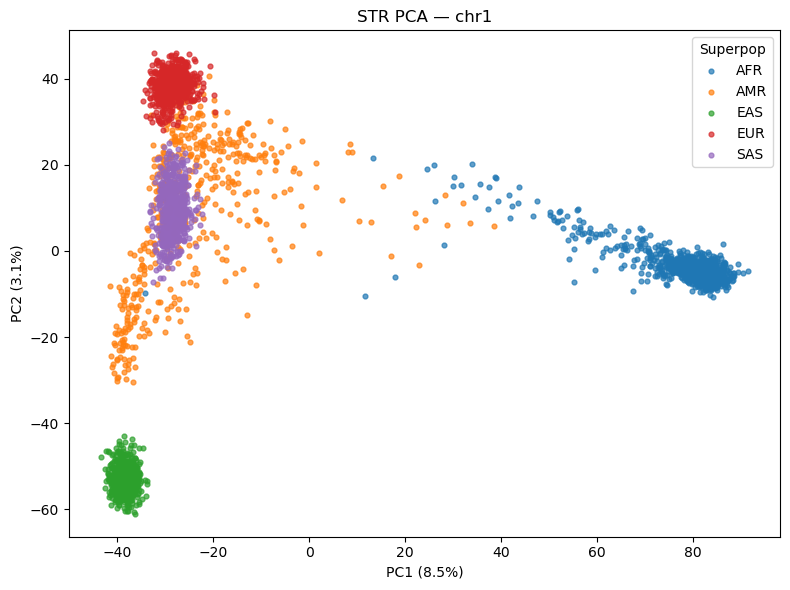

In [24]:
import matplotlib.pyplot as plt


pops = pd.read_csv('sample_type.csv')   # the same CSV as before
df_plot = pcs_df.merge(pops, on='sample', how='left')


n_unmatched = df_plot['Superpopulation'].isna().sum()
print(f'Samples without population label: {n_unmatched} / {len(df_plot)}')

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
for sp, sub in df_plot.dropna(subset=['Superpopulation']).groupby('Superpopulation'):
    ax.scatter(sub['PC1'], sub['PC2'], label=sp, s=12, alpha=0.7)
ax.set_xlabel(f'PC1 ({var_explained[0]:.1f}%)')
ax.set_ylabel(f'PC2 ({var_explained[1]:.1f}%)')
ax.set_title('STR PCA — chr1')
ax.legend(title='Superpop')
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np


merged = pcs_df.merge(pops, on='sample', how='inner')   # inner = drop unmatched
print(f'Samples with labels: {len(merged)}')
print(merged['Superpopulation'].value_counts())


feature_cols = [f'PC{i}' for i in range(1, 11)]
X = merged[feature_cols].values
y = merged['Superpopulation'].values

Samples with labels: 3202
Superpopulation
AFR    893
EUR    633
SAS    601
EAS    585
AMR    490
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Train
clf = LogisticRegression(max_iter=1000, multi_class='multinomial')
clf.fit(X_train, y_train)

# Predict on the held-out test set
y_pred = clf.predict(X_test)

# Overall accuracy
print(f'Test accuracy: {accuracy_score(y_test, y_pred):.3f}')
print('\nPer-class metrics:')
print(classification_report(y_test, y_pred))

/Users/lloyd/opt/anaconda3/envs/human_env/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Test accuracy: 0.991

Per-class metrics:
              precision    recall  f1-score   support

         AFR       0.98      0.99      0.99       179
         AMR       0.99      0.95      0.97        98
         EAS       1.00      1.00      1.00       117
         EUR       0.99      1.00      1.00       127
         SAS       1.00      1.00      1.00       120

    accuracy                           0.99       641
   macro avg       0.99      0.99      0.99       641
weighted avg       0.99      0.99      0.99       641



[[127   0   0   0   0]
 [  0 117   0   0   0]
 [  0   0 178   0   1]
 [  0   0   0 120   0]
 [  1   0   4   0  93]]


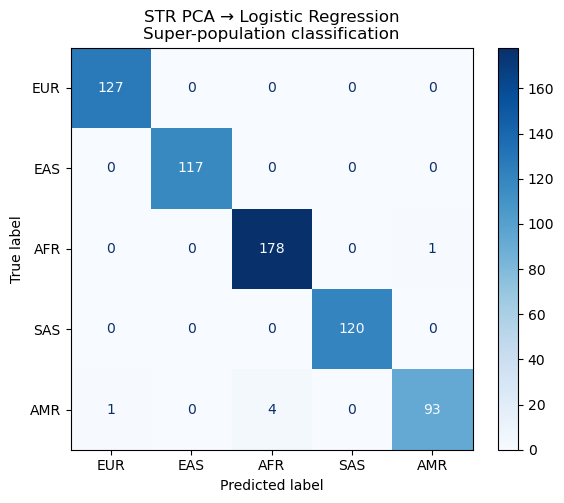

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay


labels = ['EUR', 'EAS', 'AFR', 'SAS', 'AMR']

cm = confusion_matrix(y_test, y_pred, labels=labels)
print(cm)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(ax=ax, cmap='Blues', colorbar=True, values_format='d')
ax.set_title('STR PCA → Logistic Regression\nSuper-population classification')
plt.tight_layout()
plt.show()

In [28]:
from sklearn.ensemble import RandomForestClassifier

clf2 = RandomForestClassifier(n_estimators=200, random_state=42)
clf2.fit(X_train, y_train)
y_pred2 = clf2.predict(X_test)
print(f'Random forest accuracy: {accuracy_score(y_test, y_pred2):.3f}')

Random forest accuracy: 0.992


# Answer / Interpretation Exercise 2


**Steps:**

- Filtering: Loaded the chr1 STR CSV (30,635 loci × 3,202 samples), dropped loci with >5% missingness, and median-imputed remaining missing values, yielding ~28,500 high-quality loci.

- PCA: Standardized features (z-score per locus) and computed the top 10 PCs with scikit-learn, projecting samples into the same kind of ancestry space as Exercise 1.

- Supervised classification: Trained a logistic regression classifier on PC1–PC10 to predict super-population labels, evaluated on a stratified 20% test set, and built a confusion matrix to quantify errors.

**Interpretation**: STR PCA recovers essentially the same continental structure as the SNP analysis, confirming that population structure is robust to the choice of marker type. The classifier achieves 99% test accuracy with near-perfect precision and recall for AFR, EUR, EAS, and SAS. Random forest gives the same result, indicating the data is already cleanly linearly separable in PC space. The only systematic errors occur in AMR (recall 0.95), where ~5% of admixed Latin American samples are classified as EUR or AFR — not a model failure but a direct reflection of the same biological admixture visible as multi-color bars in the ADMIXTURE plot from Exercise 1